# Train PCA + KNN and PCA + SVM

This notebook trains on one representative processed face dataset at a time. It uses the new `src.process` flow to filter subjects, preprocess images, create model inputs, and save processed artifacts before training.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent

if not (ROOT / "src").exists():
    raise RuntimeError("Could not locate repo root containing 'src'.")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

ROOT


WindowsPath('D:/HCMUTE_project/Math_for_ML/math_for_ml')

In [2]:
import pandas as pd

from src.process import PROCESSING_PRESETS, process_face_dataset_with_preset
from src.pipelines import train_pca_knn, train_pca_svm
from src.utils import compare_models, plot_confusion_matrix, plot_explained_variance, save_metrics


## Representative dataset roles

In [3]:
representative_runs = [
    {
        "dataset_name": "orl",
        "preset_name": "balanced",
        "role": "balanced",
        "description": "40 subjects x 10 images, already balanced",
    },
    {
        "dataset_name": "lfw",
        "preset_name": "many_people_many_images",
        "role": "many_people_many_images",
        "description": "many subjects kept at 15 images each",
    },
    {
        "dataset_name": "extended_yale_b",
        "preset_name": "many_images_few_people",
        "role": "many_images_few_people",
        "description": "20 subjects, 59 images each, ambient removed",
    },
]

pd.DataFrame(representative_runs).set_index("role")


,dataset_name,preset_name,description
role,,,
balanced,orl,balanced,"40 subjects x 10 images, already balanced"
many_people_many_images,lfw,many_people_many_images,many subjects kept at 15 images each
many_images_few_people,extended_yale_b,many_images_few_people,"20 subjects, 59 images each, ambient removed"


## Training config

In [4]:
representative_preset_by_dataset = {
    "orl": "balanced",
    "lfw": "many_people_many_images",
    "extended_yale_b": "many_images_few_people",
}

config = {
    "dataset_name": "orl",  # orl | lfw | extended_yale_b
    "test_size": 0.2,
    "random_state": 42,
    "n_components": 20,
    "knn_k": 3,
    "knn_metric": "euclidean",
    "svm_C": 1.0,
    "svm_kernel": "linear",
    "svm_gamma": "scale",
    "svm_max_iter": 50,
}

config["preset_name"] = representative_preset_by_dataset[config["dataset_name"]]
preset_config = PROCESSING_PRESETS[config["dataset_name"]][config["preset_name"]]

pd.Series({**config, **preset_config})


dataset_name                       orl
test_size                          0.2
random_state                        42
n_components                        20
knn_k                                3
knn_metric                   euclidean
svm_C                              1.0
svm_kernel                      linear
svm_gamma                        scale
svm_max_iter                        50
preset_name                   balanced
min_images_per_subject              10
max_images_per_subject              10
balance_subjects                  True
target_images_per_subject           10
dtype: object

## Process dataset and create model inputs

In [5]:
processed = process_face_dataset_with_preset(
    dataset_name=config["dataset_name"],
    preset_name=config["preset_name"],
    test_size=config["test_size"],
    random_state=config["random_state"],
    save_artifacts=True,
)

summary = processed["summary"]
metadata = processed["metadata"]
X = processed["X"]
y = processed["y"]
train_indices = processed["train_indices"]
test_indices = processed["test_indices"]

X_train, X_test = X[train_indices], X[test_indices]
y_train, y_test = y[train_indices], y[test_indices]
label_names = metadata["label_names"]
confusion_labels = label_names if len(label_names) <= 20 else None

pd.Series({
    "dataset_name": summary["dataset_name"],
    "preset_name": config["preset_name"],
    "samples_total": summary["samples_total"],
    "classes_total": summary["classes_total"],
    "X_train_shape": X_train.shape,
    "X_test_shape": X_test.shape,
    "stratify_used": summary["stratify_used"],
    "processed_dir": processed["output_dir"],
})


dataset_name                                                   orl
preset_name                                               balanced
samples_total                                                  400
classes_total                                                   40
X_train_shape                                         (320, 10304)
X_test_shape                                           (80, 10304)
stratify_used                                                 True
processed_dir    D:\HCMUTE_project\Math_for_ML\math_for_ml\data...
dtype: object

In [6]:
subject_filter_summary = pd.Series({
    "subjects_before_filter": summary["filter_stats"]["subjects_before_filter"],
    "subjects_after_filter": summary["filter_stats"]["subjects_after_filter"],
    "samples_before_filter": summary["filter_stats"]["samples_before_filter"],
    "samples_after_filter": summary["filter_stats"]["samples_after_filter"],
    "dropped_subject_count": summary["dropped_subject_count"],
    "truncated_subject_count": summary["truncated_subject_count"],
})
subject_filter_summary


subjects_before_filter      40
subjects_after_filter       40
samples_before_filter      400
samples_after_filter       400
dropped_subject_count        0
truncated_subject_count      0
dtype: int64

## Train PCA + KNN

In [7]:
knn_model = train_pca_knn(
    X_train,
    y_train,
    n_components=config["n_components"],
    k=config["knn_k"],
    metric=config["knn_metric"],
)

knn_eval = knn_model.evaluate(X_test, y_test)
pd.Series({
    "accuracy": knn_eval["accuracy"],
    "train_time": knn_eval["train_time"],
})


accuracy      0.925000
train_time    0.175896
dtype: float64

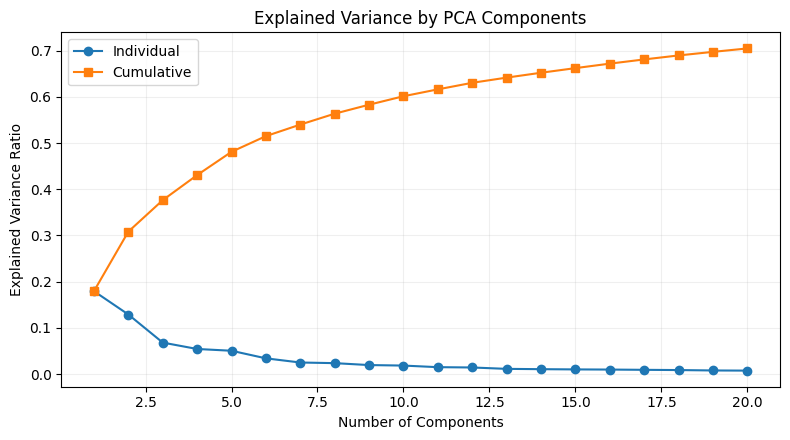

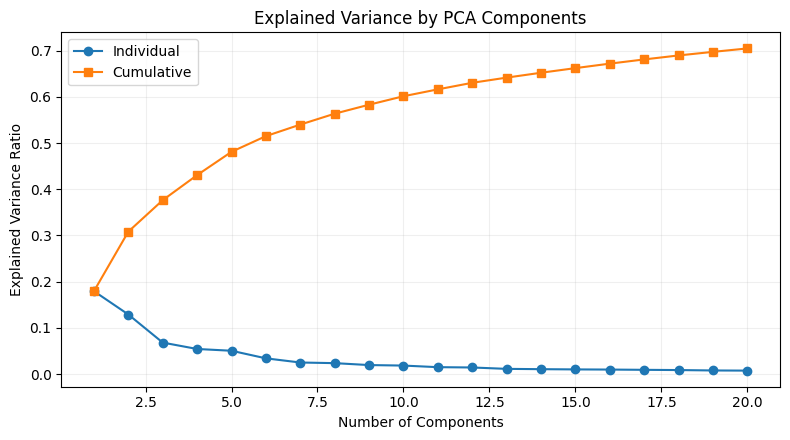

In [8]:
plot_explained_variance(knn_model.pca.explained_variance_ratio_)


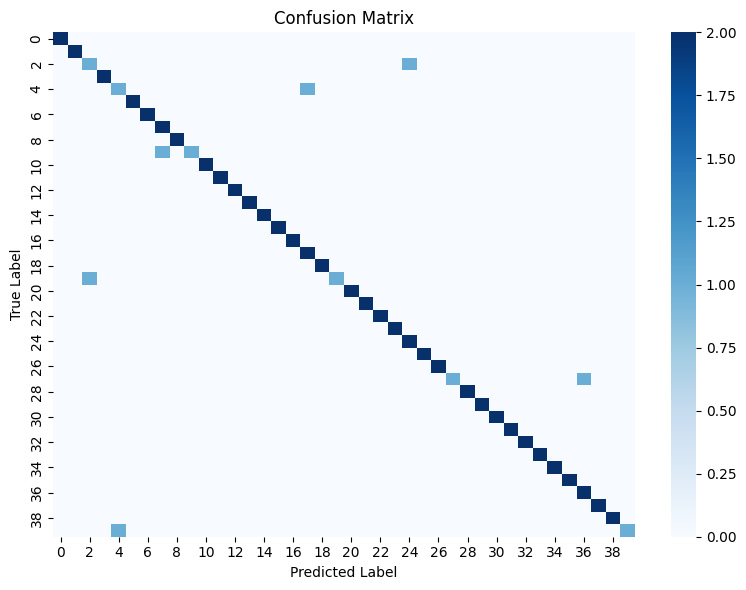

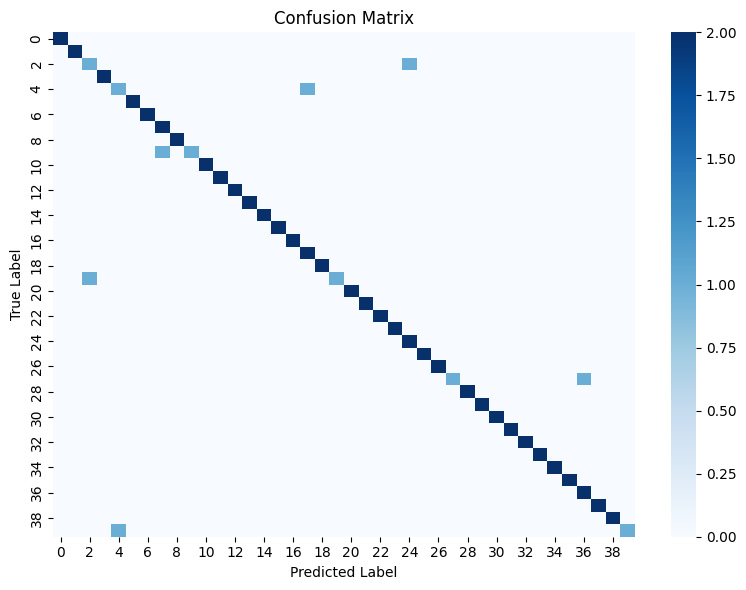

In [9]:
plot_confusion_matrix(knn_eval["confusion_matrix"], labels=confusion_labels)


## Train PCA + SVM

In [10]:
svm_model = train_pca_svm(
    X_train,
    y_train,
    n_components=config["n_components"],
    C=config["svm_C"],
    kernel=config["svm_kernel"],
    gamma=config["svm_gamma"],
    max_iter=config["svm_max_iter"],
)

svm_eval = svm_model.evaluate(X_test, y_test)
pd.Series({
    "accuracy": svm_eval["accuracy"],
    "train_time": svm_eval["train_time"],
})


accuracy      0.962500
train_time    1.350671
dtype: float64

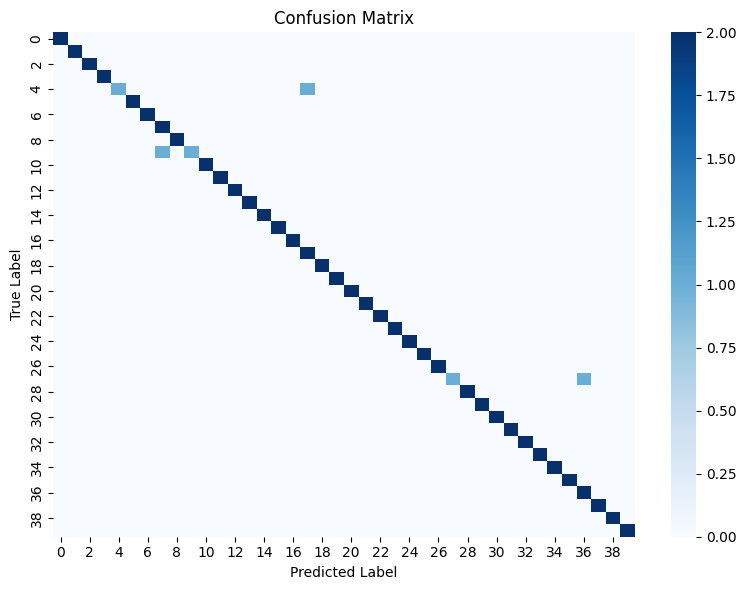

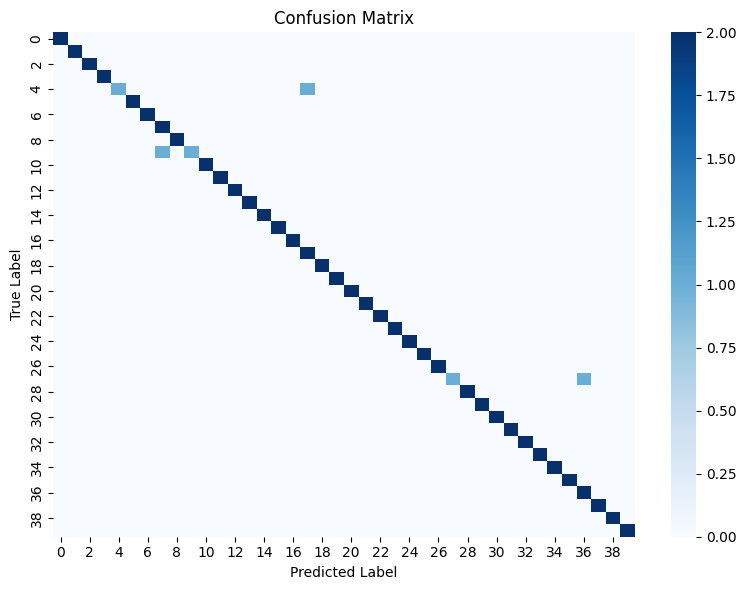

In [11]:
plot_confusion_matrix(svm_eval["confusion_matrix"], labels=confusion_labels)


## Compare and save metrics

In [12]:
comparison = compare_models(
    (knn_eval, "PCA+KNN"),
    (svm_eval, "PCA+SVM"),
)
comparison


         Accuracy  Precision  Recall  F1-Score  Train Time
Model                                                     
PCA+KNN    0.9250     0.9417  0.9250    0.9217       0.176
PCA+SVM    0.9625     0.9750  0.9625    0.9600       1.351


,Accuracy,Precision,Recall,F1-Score,Train Time
Model,,,,,
PCA+KNN,0.9250,0.9417,0.9250,0.9217,0.176
PCA+SVM,0.9625,0.9750,0.9625,0.9600,1.351


In [13]:
metrics_path = ROOT / "results" / "metrics" / f"notebook_comparison_{config['dataset_name']}_{config['preset_name']}.csv"
save_metrics(comparison, metrics_path)
metrics_path


[metrics] Đã lưu: D:\HCMUTE_project\Math_for_ML\math_for_ml\results\metrics\notebook_comparison_orl_balanced.csv


WindowsPath('D:/HCMUTE_project/Math_for_ML/math_for_ml/results/metrics/notebook_comparison_orl_balanced.csv')

## Optional: save trained models

In [14]:
knn_model_path = ROOT / "webapp" / "saved_models" / f"pca_knn_{config['dataset_name']}_{config['preset_name']}_notebook.joblib"
svm_model_path = ROOT / "webapp" / "saved_models" / f"pca_svm_{config['dataset_name']}_{config['preset_name']}_notebook.joblib"

knn_model.save(knn_model_path)
svm_model.save(svm_model_path)
svm_model_path


WindowsPath('D:/HCMUTE_project/Math_for_ML/math_for_ml/webapp/saved_models/pca_svm_orl_balanced_notebook.joblib')